In [1]:
# ====== Import thư viện ======
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tqdm import tqdm

# ====== Đường dẫn ảnh ======
IMAGE_DIR = "photos_no_class"   # thay bằng thư mục chứa ảnh của bạn
image_paths = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith((".jpg", ".png"))]

print("Số lượng ảnh:", len(image_paths))

# ====== Load mô hình VGG16 pretrained (bỏ phần fully-connected) ======
base_model = VGG16(weights="imagenet")
model = Model(inputs=base_model.input, outputs=base_model.get_layer("fc1").output)
print("Output feature vector size:", model.output.shape)


Số lượng ảnh: 80
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 54s 0us/step
Output feature vector size: (None, 4096)


In [2]:
# ====== Hàm load & tiền xử lý ảnh ======
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feature = model.predict(x, verbose=0)
    return feature.flatten()

# ====== Trích feature cho toàn bộ ảnh ======
features = []
for p in tqdm(image_paths):
    features.append(extract_feature(p))

features = np.array(features)
print("Feature matrix shape:", features.shape)


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [01:01<00:00,  1.29it/s]

Feature matrix shape: (80, 4096)


In [3]:
pca = PCA(n_components=50)
features_reduced = pca.fit_transform(features)

print("Shape sau PCA:", features_reduced.shape)


Shape sau PCA: (80, 50)


In [4]:
k = 3  # số cụm muốn phân
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(features_reduced)

print("Nhãn cụm:", labels)


Nhãn cụm: [1 0 0 0 2 0 0 2 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


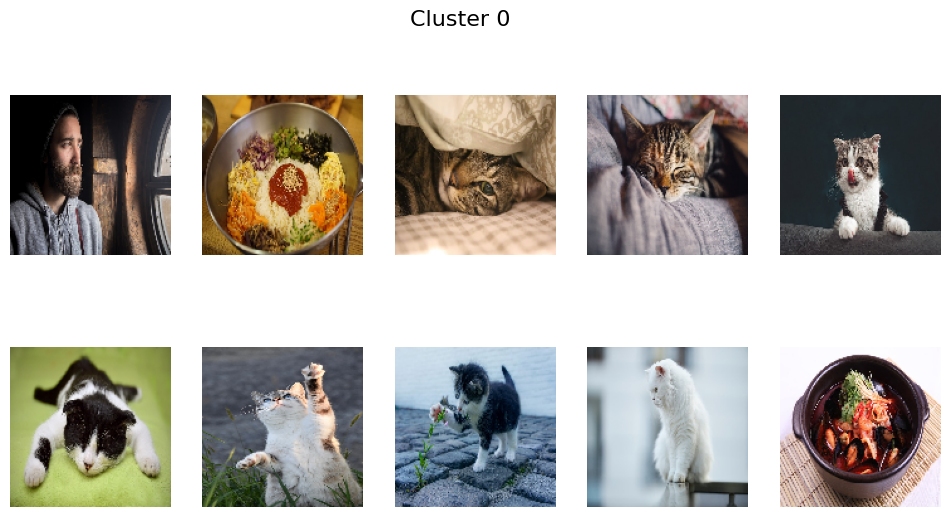

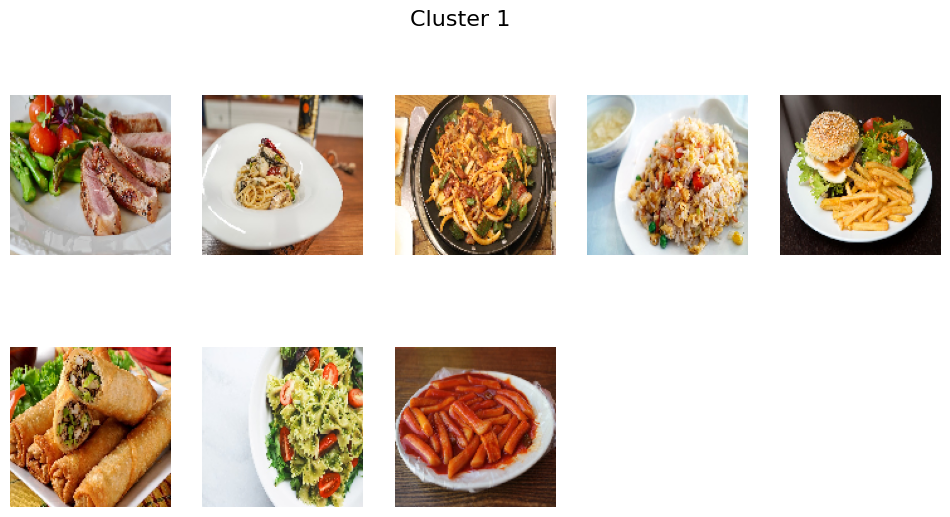

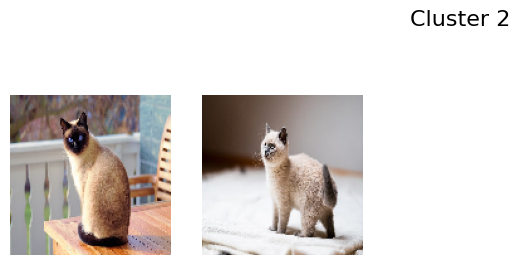

In [5]:
def show_cluster(cluster_id):
    plt.figure(figsize=(12, 6))
    idx = np.where(labels == cluster_id)[0]
    for i, index in enumerate(idx[:10]):   # hiển thị 10 ảnh đầu tiên
        img = image.load_img(image_paths[index], target_size=(128, 128))
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"Cluster {cluster_id}", fontsize=16)
    plt.show()

for c in range(k):
    show_cluster(c)


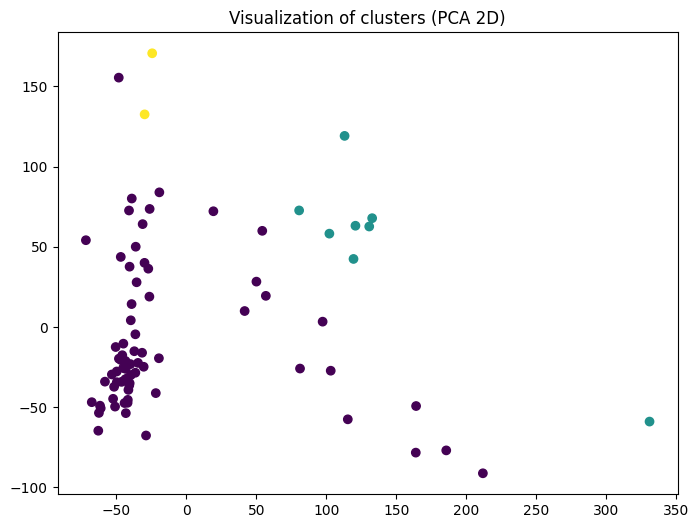

In [6]:
# Giảm chiều xuống 2 thành phần
pca_2d = PCA(n_components=2)
points_2d = pca_2d.fit_transform(features_reduced)

plt.figure(figsize=(8, 6))
plt.scatter(points_2d[:, 0], points_2d[:, 1], c=labels)
plt.title("Visualization of clusters (PCA 2D)")
plt.show()
